# 01. Comprensión y auditoría de los datos OULAD

Revisión del 10 de septiembre de 2026. Objetivo específico 1; CRISP-DM: comprensión
de los datos. Se examinan las fuentes completas, sin filtrar todavía la población
predictiva. La unidad de análisis es la inscripción (persona, módulo y presentación).
Los resultados se calculan a partir de los CSV; las salidas anteriores se conservan
en `respaldo/2026-09-08_pre_revision`.

El descriptor de Kuzilek, Hlosta y Zdrahal (2017), *Open University Learning Analytics
dataset*, Scientific Data 4, 170171, DOI: 10.1038/sdata.2017.171, documenta las tablas.
Los registros VLE son resúmenes de clics y no identificadores de sesión. La revisión
no interpreta las repeticiones como sesiones ni elimina registros sin evidencia.

Actualización multiventana: se conserva la auditoría completa de la fuente y se añade sensibilidad de registros repetidos en los cortes 7, 14, 28, 42 y 56. La sensibilidad histórica 0-27 se conserva identificada como antecedente.


In [1]:
import os, sys, json
from pathlib import Path
candidate = Path(os.environ.get('OULAD_ROOT', Path.cwd())).resolve()
ROOT = next(p for p in [candidate, *candidate.parents] if (p / 'data/raw/studentInfo.csv').exists())
sys.path.insert(0, str(ROOT / 'src'))
from oulad_revision import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
print(environment())


{'python': '3.11.9', 'packages': {'pandas': '2.3.3', 'numpy': '2.4.4', 'scipy': '1.17.1', 'matplotlib': '3.10.9', 'scikit-learn': '1.8.0', 'pyarrow': '24.0.0'}}


## 1. Fuentes, dimensiones y trazabilidad
Se registran las huellas SHA-256 de los siete archivos. Estas huellas permiten
comprobar la identidad de las fuentes utilizadas; no certifican por sí mismas su
coincidencia con una descarga oficial. Los CSV originales se conservan intactos.


In [2]:
names = ['courses', 'assessments', 'vle', 'studentInfo', 'studentRegistration', 'studentAssessment', 'studentVle']
tables = {name: load(name) for name in names}
courses, assessments, vle, info, registration, sa, sv = [tables[n] for n in names]
manifest = {name: {'sha256': sha256(RAW / f'{name}.csv'), 'bytes': (RAW / f'{name}.csv').stat().st_size} for name in names}
save_json('fuentes.json', manifest)
save_json('entorno.json', environment())
dimensions = table('01_dimensiones', pd.DataFrame([
    {'tabla': n, 'filas': len(d), 'columnas': len(d.columns), 'memoria_MB': round(d.memory_usage(deep=True).sum()/1e6, 2)}
    for n, d in tables.items()]))
missing = table('01_faltantes', pd.DataFrame([
    {'tabla': n, 'variable': v, 'n': len(d), 'faltantes': int(d[v].isna().sum()),
     'porcentaje': 100*d[v].isna().mean(), 'tipo': str(d[v].dtype)}
    for n, d in tables.items() for v in d.columns if d[v].isna().any()]))


01_dimensiones
              tabla    filas  columnas  memoria_MB
            courses       22         3        0.00
        assessments      206         6        0.02
                vle     6364         6        0.58
        studentInfo    32593        12       15.52
studentRegistration    32593         5        0.85
  studentAssessment   173912         5        6.96
         studentVle 10655280         6      234.42
01_faltantes
              tabla            variable      n  faltantes  porcentaje    tipo
        assessments                date    206         11    5.339806 float64
                vle           week_from   6364       5243   82.385292 float64
                vle             week_to   6364       5243   82.385292 float64
        studentInfo            imd_band  32593       1111    3.408707  object
studentRegistration   date_registration  32593         45    0.138066 float64
studentRegistration date_unregistration  32593      22521   69.097659 float64
  studentAssessmen

## 2. Claves y registros repetidos
Se comprueban claves de entidades y relaciones completas. Una repetición exacta del
log no puede clasificarse como error de captura o sesión adicional solo con estos
campos. Se conserva la suma original y se calcula una sensibilidad al retirar
repeticiones exactas, únicamente como escenario alternativo de procesamiento.


In [3]:
keys = {'courses': COURSE, 'assessments': ['id_assessment'], 'vle': ['id_site'],
        'studentInfo': KEY, 'studentRegistration': KEY,
        'studentAssessment': ['id_student', 'id_assessment'],
        'studentVle': KEY + ['id_site', 'date']}
duplicates = table('01_duplicados', pd.DataFrame([
    {'tabla': n, 'exactos': int(d.duplicated().sum()),
     'repetidos_clave': int(d.duplicated(keys[n]).sum()),
     'nulos_clave': int(d[keys[n]].isna().any(axis=1).sum())} for n, d in tables.items()]))
for n in names[:-1]:
    assert not tables[n].duplicated(keys[n]).any(), f'Clave no única: {n}'
    assert not tables[n][keys[n]].isna().any().any(), f'Clave nula: {n}'
early = sv.loc[sv.date.between(0, 27)]
raw_clicks = early.groupby(KEY, observed=True).sum_click.sum().rename('clics_originales')
dedup_clicks = early.drop_duplicates().groupby(KEY, observed=True).sum_click.sum().rename('clics_sin_exactos')
sensitivity = raw_clicks.to_frame().join(dedup_clicks)
sensitivity['diferencia'] = sensitivity.clics_originales - sensitivity.clics_sin_exactos
sensitivity.to_parquet(PROCESSED / 'sensibilidad_duplicados.parquet')
duplicate_summary = {'registros_exactos_tempranos': int(early.duplicated().sum()),
    'inscripciones_afectadas': int(sensitivity.diferencia.gt(0).sum()),
    'clics_originales': int(raw_clicks.sum()), 'clics_sin_exactos': int(dedup_clicks.sum())}
print(duplicate_summary)


01_duplicados
              tabla  exactos  repetidos_clave  nulos_clave
            courses        0                0            0
        assessments        0                0            0
                vle        0                0            0
        studentInfo        0                0            0
studentRegistration        0                0            0
  studentAssessment        0                0            0
         studentVle   787170          2195960            0
{'registros_exactos_tempranos': 140592, 'inscripciones_afectadas': 22770, 'clics_originales': 7781403, 'clics_sin_exactos': 7526875}


## 3. Integridad referencial
Las verificaciones utilizan la inscripción completa y la pertenencia del recurso
al módulo y presentación. Se comprueban identificadores de evaluación antes de
enriquecer las entregas; un `inner join` no debe ocultar registros sin correspondencia.


In [4]:
regkeys, infokeys = keyset(registration, KEY), keyset(info, KEY)
coursekeys = keyset(courses, COURSE)
sa_meta = sa.merge(assessments, on='id_assessment', how='left', validate='many_to_one', indicator=True)
sitekeys = keyset(vle, COURSE + ['id_site'])
relations = {
    'inscripciones_info_sin_registro': len(infokeys - regkeys),
    'inscripciones_registro_sin_info': len(regkeys - infokeys),
    'entregas_sin_evaluacion': int(sa_meta['_merge'].eq('left_only').sum()),
    'inscripciones_entregas_sin_registro': len(keyset(sa_meta, KEY) - regkeys),
    'inscripciones_vle_sin_registro': len(keyset(sv[KEY].drop_duplicates(), KEY) - regkeys),
    'recursos_con_modulo_presentacion_incorrectos': len(keyset(sv[COURSE+['id_site']].drop_duplicates(), COURSE+['id_site']) - sitekeys),
    'inscripciones_sin_presentacion': len(keyset(registration, COURSE) - coursekeys),
    'evaluaciones_sin_presentacion': len(keyset(assessments, COURSE) - coursekeys),
    'recursos_sin_presentacion': len(keyset(vle, COURSE) - coursekeys),
}
table('01_integridad', pd.DataFrame(relations.items(), columns=['verificacion', 'casos']))
assert all(v == 0 for v in relations.values()), 'Resolver integridad antes de continuar'
base = registration.merge(info, on=KEY, validate='one_to_one').merge(courses, on=COURSE, validate='many_to_one')
assert len(base) == len(registration)
population = {'inscripciones': len(base), 'personas': int(base.id_student.nunique()),
              'personas_con_varias_inscripciones': int(base.groupby('id_student').size().gt(1).sum()),
              'modulos': int(base.code_module.nunique()), 'presentaciones_modulo': len(courses)}
print(population)


01_integridad
                                verificacion  casos
             inscripciones_info_sin_registro      0
             inscripciones_registro_sin_info      0
                     entregas_sin_evaluacion      0
         inscripciones_entregas_sin_registro      0
              inscripciones_vle_sin_registro      0
recursos_con_modulo_presentacion_incorrectos      0
              inscripciones_sin_presentacion      0
               evaluaciones_sin_presentacion      0
                   recursos_sin_presentacion      0
{'inscripciones': 32593, 'personas': 28785, 'personas_con_varias_inscripciones': 3538, 'modulos': 7, 'presentaciones_modulo': 22}


## 4. Rangos, calendario y consistencia temporal
Las fechas negativas son posibles en OULAD y no se eliminan automáticamente. Los
pesos se examinan separando evaluaciones continuas y exámenes; no se impone que toda
presentación deba sumar 200. Un puntaje ausente se distingue de la falta de entrega.
La fecha de entrega no acredita cuándo estuvo disponible su calificación.


In [5]:
ranges = {
    'puntajes_fuera_0_100': int((sa.score.notna() & ~sa.score.between(0, 100)).sum()),
    'puntajes_ausentes': int(sa.score.isna().sum()),
    'clics_no_positivos': int(sv.sum_click.le(0).sum()),
    'pesos_fuera_0_100': int((~assessments.weight.between(0, 100)).sum()),
    'retiros_antes_matricula': int(base.date_unregistration.lt(base.date_registration).sum()),
    'matriculas_sin_fecha': int(base.date_registration.isna().sum()),
    'matriculas_despues_dia28': int(base.date_registration.gt(28).sum()),
    'retiros_despues_final_presentacion': int(base.date_unregistration.gt(base.module_presentation_length).sum()),
    'entregas_antes_dia0': int(sa.date_submitted.lt(0).sum()),
    'entregas_reconocidas_banked': int(sa.is_banked.eq(1).sum()),
    'bandera_banked_fuera_0_1': int((~sa.is_banked.isin([0, 1])).sum()),
}
table('01_rangos', pd.DataFrame(ranges.items(), columns=['verificacion', 'casos']))
table('01_pesos', assessments.assign(grupo=np.where(assessments.assessment_type.eq('Exam'), 'Exam', 'Continua'))
      .groupby(COURSE+['grupo'], observed=True).agg(n=('id_assessment','size'), peso=('weight','sum')).reset_index())
table('01_fechas_evaluacion_ausentes', assessments.loc[assessments.date.isna(), COURSE+['id_assessment','assessment_type']])
daily = sv.groupby(KEY+['date'], observed=True).agg(clics=('sum_click','sum'), registros=('sum_click','size')).reset_index()
daily_reg = daily.merge(registration, on=KEY, how='left', validate='many_to_one')
ranges['registros_vle_antes_matricula'] = int(daily_reg.loc[daily_reg.date.lt(daily_reg.date_registration), 'registros'].sum())
ranges['registros_vle_despues_retiro'] = int(daily_reg.loc[daily_reg.date.gt(daily_reg.date_unregistration), 'registros'].sum())
sa_dates = sa_meta.drop(columns='_merge').merge(registration, on=KEY, how='left', validate='many_to_one')
ranges['entregas_despues_retiro'] = int(sa_dates.date_submitted.gt(sa_dates.date_unregistration).sum())
table('01_consistencia_temporal', pd.DataFrame(ranges.items(), columns=['verificacion','casos']))
assert ranges['puntajes_fuera_0_100'] == ranges['clics_no_positivos'] == ranges['bandera_banked_fuera_0_1'] == 0


01_rangos
                      verificacion  casos
              puntajes_fuera_0_100      0
                 puntajes_ausentes    173
                clics_no_positivos      0
                 pesos_fuera_0_100      0
           retiros_antes_matricula      0
              matriculas_sin_fecha     45
          matriculas_despues_dia28     16
retiros_despues_final_presentacion      1
               entregas_antes_dia0   2057
       entregas_reconocidas_banked   1909
          bandera_banked_fuera_0_1      0
01_pesos
code_module code_presentation    grupo  n  peso
        AAA             2013J Continua  5 100.0
        AAA             2013J     Exam  1 100.0
        AAA             2014J Continua  5 100.0
        AAA             2014J     Exam  1 100.0
        BBB             2013B Continua 11 100.0
        BBB             2013B     Exam  1 100.0
        BBB             2013J Continua 11 100.0
        BBB             2013J     Exam  1 100.0
        BBB             2014B Continua 11 100

## 5. Retiro registrado y resultado final
La presencia de una fecha de retiro constituye el evento administrativo observado.
No prueba por sí sola el motivo voluntario del retiro. `Withdrawn` se contrasta con
esta definición, sin sustituirla automáticamente. Los retiros del día 28 se separan
de los eventos futuros; las cifras de toda la fuente no son prevalencias de la
población elegible para predicción.


01_momento_retiro
momento_retiro  inscripciones  personas  pct_todas_inscripciones
  antes_inicio           2678      2534                 8.216488
    despues_28           5017      4649                15.392876
        dia_28             15        15                 0.046022
     dias_0_27           2362      2224                 7.246955
     sin_fecha          22521     21190                69.097659
01_retiro_resultado
 retiro_registrado  Distinction  Fail  Pass  Withdrawn
                 0         3024  7043 12361         93
                 1            0     9     0      10063


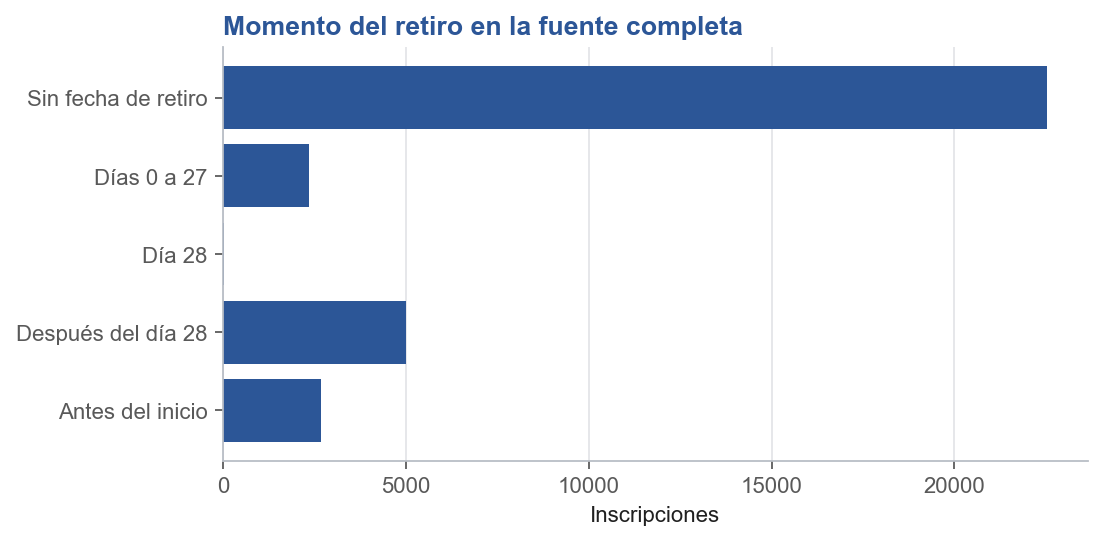

In [6]:
base['retiro_registrado'] = base.date_unregistration.notna().astype('int8')
base['momento_retiro'] = np.select([
    base.date_unregistration.isna(), base.date_unregistration.lt(0),
    base.date_unregistration.lt(28), base.date_unregistration.eq(28)],
    ['sin_fecha', 'antes_inicio', 'dias_0_27', 'dia_28'], default='despues_28')
segments = base.groupby('momento_retiro', observed=True).agg(inscripciones=('id_student','size'), personas=('id_student','nunique')).reset_index()
segments['pct_todas_inscripciones'] = 100*segments.inscripciones/len(base)
table('01_momento_retiro', segments)
cross = pd.crosstab(base.retiro_registrado, base.final_result).reset_index()
table('01_retiro_resultado', cross)
discrepancy = base.retiro_registrado.ne(base.final_result.eq('Withdrawn').astype(int))
base.loc[discrepancy, KEY+['date_unregistration','final_result']].to_csv(OUT/'tablas/01_discrepancias_retiro.csv', index=False)
from figuras_oulad import momento_retiro
momento_retiro(segments)
figure('01_momento_retiro')


## Sensibilidad de registros repetidos en los cinco cortes
Se compara la suma original con el escenario de retirar filas exactamente repetidas,
sin afirmar que la segunda alternativa sea la verdadera. Las ventanas incluyen el
día del corte y la población de esta tabla es toda la fuente, no solo elegibles.


In [7]:
cuts=json.loads((ROOT/'decision_temporal.json').read_text(encoding='utf-8'))['cortes']
dup_windows=[]
for cut in cuts:
    x=sv.loc[sv.date.between(0,cut)]
    alternate=x.drop_duplicates()
    original=x.groupby(KEY,observed=True).sum_click.sum()
    alternative=alternate.groupby(KEY,observed=True).sum_click.sum().reindex(original.index,fill_value=0)
    dup_windows.append({'corte':cut,'registros':len(x),'exactos_adicionales':len(x)-len(alternate),
      'clics_originales':int(original.sum()),'clics_sin_exactos':int(alternative.sum()),
      'reduccion_pct':100*(original.sum()-alternative.sum())/original.sum(),
      'inscripciones_afectadas':int(original.ne(alternative).sum())})
table('01_sensibilidad_cortes',pd.DataFrame(dup_windows))


01_sensibilidad_cortes
 corte  registros  exactos_adicionales  clics_originales  clics_sin_exactos  reduccion_pct  inscripciones_afectadas
     7     632165                40467           2218326            2140648       3.501649                    14601
    14    1130789                74986           4047355            3906767       3.473577                    18862
    28    2158863               143696           7945783            7685825       3.271647                    22837
    42    2914058               197917          10656511           10303183       3.315607                    23834
    56    3642556               252290          13256804           12815335       3.330131                    24706
   corte  registros  exactos_adicionales  clics_originales  clics_sin_exactos  \
0      7     632165                40467           2218326            2140648   
1     14    1130789                74986           4047355            3906767   
2     28    2158863               1436

## 6. Exportación y límites
El panel diario conserva la suma de todos los registros originales. Los registros
anteriores a la matrícula y posteriores al retiro se cuantifican como discrepancias
de fechas administrativas; no se les atribuye una causa sin evidencia. El notebook
02 establecerá una población en riesgo y separará los indicadores retrospectivos.
Las asociaciones y decisiones de modelado todavía no se evalúan en esta etapa.


In [8]:
daily.to_parquet(PROCESSED/'actividad_diaria.parquet', index=False)
sa_meta.drop(columns='_merge').to_parquet(PROCESSED/'entregas_metadatos.parquet', index=False)
base.to_parquet(PROCESSED/'base_auditoria.parquet', index=False)
save_json('01_resumen.json', {'poblacion': population, 'rangos': ranges,
    'duplicados_tempranos': duplicate_summary, 'integridad': relations,
    'retiros_registrados': int(base.retiro_registrado.sum()),
    'discrepancias_retiro_resultado': int(discrepancy.sum())})
print('Auditoría completa y artefactos exportados.')

# Sensibilidad: quitar exactos en todas las columnas antes de agregar.
clean=sv.drop_duplicates()
dedup_daily=clean.groupby(KEY+['date'],observed=True).agg(clics=('sum_click','sum'),registros=('sum_click','size')).reset_index()
dedup_daily.to_parquet(PROCESSED/'actividad_diaria_sin_exactos.parquet',index=False)


Auditoría completa y artefactos exportados.
